# Experiment 5 — Mode-Switch Confound Control

| Field | Value |
|---|---|
| **Author** | Elad Moshe |
| **Mentor** | Prof. Luciano Pezzuti |
| **Institution** | IE Madrid — MSc Computer Science |
| **Date** | June 2026 |
| **Role** | Confound control for Experiment 1 (exp1_residual_stream_regression) |
| **Priority** | MUST-HAVE |

> **AI Assistance Disclaimer:** Code scaffolding, documentation, and structural outlines in this notebook were generated with Claude (Anthropic). All experimental design, hypothesis framing, and interpretation are the original work of the author. AI-generated code has been reviewed and validated before execution.

## Notebook Overview

### Research Question

Does the logistic-regression classifier in **Experiment 1** (`exp1_residual_stream_regression`) detect **correctness** in the layer-12 residual stream, or does it merely detect the **prompt format** (CoT vs. NoCoT)?

### Background

Exp 1 trains an LR on Gemma-2-2B layer-12 residual-stream vectors from **GSM8K (n=400, seed=42)** to distinguish correct from incorrect answers.

| Condition | Position | Layer | Real AUROC (exp1) |
|---|---|---|---|
| CoT | pos_a | 12 | 0.770 |
| NoCoT | pos_a | 12 | 0.730 |
| CoT | pos_b | 12 | 0.666 |
| NoCoT | pos_b | 12 | 0.736 |

*(Reference values loaded dynamically from `exp1/backup/lr_results.csv` in Section 1.)*

### Mode-Switch Test Design

Take only **correctly-answered** problems from both conditions and train a new classifier:

- **Class 1 — CoT-correct:** GSM8K problems solved correctly *with* chain-of-thought
- **Class 0 — NoCoT-correct:** GSM8K problems solved correctly *without* chain-of-thought

Both groups answered correctly; the only systematic difference is **prompt format**.

| Mode-switch AUROC | Interpretation |
|---|---|
| **≈ 0.5** | ✓ Classifier cannot distinguish formats → Exp 1 encodes correctness, not format |
| **≈ Exp 1 AUROC** | ✗ Classifier detects prompt format → confound present |
| **Between** | Partial confound — report both experiments together |

### Activation Source

Layer-12 residual-stream vectors are loaded from **Exp 2's cache** (`exp2_sae_decomposition/backup/cache/`). The raw residual stream is recovered as:

```
raw = reconstructed + error
```

No GPU is needed if these files are already on Drive. The model capture path (Section 1f) is only entered if the `.npy` files are missing.

### Storage Policy

> **All outputs write directly to Google Drive** via `CACHE_DIR` and `FIGURES_DIR`. Nothing is written to Colab's ephemeral `/content` filesystem.

## Table of Contents

0. [Setup & Drive Mount](#0-setup--drive-mount)
1. [Load Data (Activations + Labels)](#1-load-data)
   - 1f. [Capture Missing Activations (conditional)](#1f-capture-missing-activations)
2. [Subset Correct Activations](#2-subset-correct-activations)
3. [Mode-Switch Logistic Regression](#3-mode-switch-logistic-regression)
4. [Comparison & Visualisation](#4-comparison--visualisation)
5. [Final Results Snapshot](#5-final-results-snapshot)
6. [Results & Interpretation](#6-results--interpretation)

## 0 — Setup & Drive Mount

In [ ]:
# ── 0a: Detect environment & install dependencies ────────────────────────────
# transformers/accelerate are only used in the slow-path model capture (Section 1f).
# All other sections require only standard data-science packages.

try:
    import google.colab
    IN_COLAB = True
    %pip install -q transformers accelerate datasets huggingface_hub \
        pandas numpy matplotlib seaborn scipy statsmodels tqdm scikit-learn
except ImportError:
    IN_COLAB = False
    try:
        from dotenv import load_dotenv
        load_dotenv()
    except ImportError:
        pass

print(f"Environment: {'Google Colab' if IN_COLAB else 'Local'}")

Environment: Google Colab


In [ ]:
# ── 0b: Mount Google Drive & auto-detect permanent storage paths ─────────────
#
# Uses the EXACT same _find_notebook_dir as exp3_logprob_mean (which worked).
# Strategy 1 (fast): walk one level under MyDrive — catches shortcuts directly.
# Strategy 2 (fallback): find -L to follow symlinks inside Computers.

from google.colab import drive
from pathlib import Path
import subprocess

drive.mount('/content/drive')

def _find_notebook_dir(name: str) -> Path:
    my_drive = Path('/content/drive/MyDrive')
    if my_drive.exists():
        top = sorted(d for d in my_drive.iterdir() if d.is_dir())
        print(f'  MyDrive entries: {[d.name for d in top]}')
        for entry in top:
            if entry.name == name:
                return entry
            candidate = entry / name
            if candidate.exists():
                return candidate
    else:
        print('  /content/drive/MyDrive not found — check Drive mount.')
    roots = ([str(my_drive)] if my_drive.exists() else [])
    computers = Path('/content/drive/Computers')
    if computers.exists():
        roots.append(str(computers))
    for root in roots:
        print(f'  Falling back to find -L in {Path(root).name}...')
        r = subprocess.run(
            ['find', '-L', root, '-maxdepth', '20', '-type', 'd', '-name', name],
            capture_output=True, text=True, timeout=240,
        )
        hits = [p.strip() for p in r.stdout.strip().split('\n')
                if p.strip() and '/backup' not in p and '/.Trash' not in p]
        if hits:
            return Path(hits[0])
    top_names = ([d.name for d in my_drive.iterdir()] if my_drive.exists() else [])
    raise RuntimeError(
        f'Could not find "{name}" in Drive.\n'
        f'  MyDrive contents: {top_names}\n\n'
        'To fix — pick ONE option:\n'
        '  A) Shortcut: drive.google.com -> find the "experiments" folder\n'
        '     -> Right-click -> Organize -> Add shortcut -> My Drive\n'
        '     Then re-run this cell.\n\n'
        '  B) Manual override — add this line BEFORE the _find_notebook_dir() call:\n'
        '     NOTEBOOK_DIR = Path("/content/drive/MyDrive/<folder>/exp5_mode_switch_control")\n'
        '     (use the MyDrive contents list above to find the right parent)'
    )

print('Auto-detecting notebook folder in Drive...')
NOTEBOOK_DIR = _find_notebook_dir('exp5_mode_switch_control')

BACKUP_DIR  = NOTEBOOK_DIR / 'backup'
CACHE_DIR   = BACKUP_DIR / 'cache'
FIGURES_DIR = BACKUP_DIR / 'figures'

CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Exp1 cache — canonical sibling path first, then top-level shortcut (exp1_cache)
_exp1_new = NOTEBOOK_DIR.parent / 'exp1_residual_stream_regression' / 'backup' / 'cache'
_exp1_old = Path('/content/drive/MyDrive/exp1_cache')
if _exp1_new.exists():
    EXP1_CACHE = _exp1_new
elif _exp1_old.exists():
    print(f'  exp1 cache found at shortcut location: {_exp1_old}')
    EXP1_CACHE = _exp1_old
else:
    EXP1_CACHE = _exp1_old   # will be checked gracefully in later cells

# Exp2 cache — canonical sibling path first, then top-level shortcut (exp2_cache)
_exp2_new = NOTEBOOK_DIR.parent / 'exp2_sae_decomposition' / 'backup' / 'cache'
_exp2_old = Path('/content/drive/MyDrive/exp2_cache')
if _exp2_new.exists():
    EXP2_CACHE = _exp2_new
elif _exp2_old.exists():
    print(f'  exp2 cache found at shortcut location: {_exp2_old}')
    EXP2_CACHE = _exp2_old
else:
    EXP2_CACHE = _exp2_new   # will be checked gracefully in later cells

EXP1_BACKUP = EXP1_CACHE   # same root — parquets live directly in exp1_cache/

print(f'Drive ready.')
print(f'  Notebook : {NOTEBOOK_DIR}')
print(f'  Cache    : {CACHE_DIR}')
print(f'  Figures  : {FIGURES_DIR}')
print(f'  Exp1     : {EXP1_CACHE}  (exists={EXP1_CACHE.exists()})')
print(f'  Exp2     : {EXP2_CACHE}  (exists={EXP2_CACHE.exists()})')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Auto-detecting notebook folder in Drive...
  MyDrive entries: ['Colab Notebooks', 'Elad Moshe - MSc in CS', 'Research Capstone - Elad (LLM Reasoning)', 'University', 'exp1_cache', 'exp1_figures', 'experiments', 'experiments (1)', 'h1_checkpoints', 'h1_runs', 'research capstone', 'אלעד משה - תואר שני', 'אלעד משה - תואר שני (1)', 'דרייב מחו"ג', 'כספות', 'מדמ"ח', 'מדעי המחשב', 'מדעי המחשב ישן ', 'מעבדות עותק', 'מעבדות פיזיקה אלעד משה', 'מערכות הפעלה', 'מערכות הפעלה (1)', 'סרטים להגות צבאית', 'פייתון תיכון', 'רב תחומי', 'שנה שלישית - חבצלות', 'תיק השקעות', 'תיקיית יב - תמונות']
  exp1 cache found at shortcut location: /content/drive/MyDrive/exp1_cache
Drive ready.
  Notebook : /content/drive/MyDrive/experiments/exp5_mode_switch_control
  Cache    : /content/drive/MyDrive/experiments/exp5_mode_switch_control/backup/cache
  Figures  : /content/drive/MyDrive/experim

In [ ]:
# ── 0c: Imports & analysis constants ─────────────────────────────────────────

assert not IN_COLAB or '/content/drive/' in str(CACHE_DIR), (
    'CACHE_DIR is not on Google Drive. Run the Drive mount cell first.'
)

import os, json, re, random, getpass, pickle, warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.titlesize': 12, 'figure.facecolor': 'white',
})

# ── Classifier hyperparameters — match exp1 exactly ───────────────────────────
MODEL_NAME = 'google/gemma-2-2b'
LAYER      = 12          # layer where the mode-switch test is performed
D_MODEL    = 2304
N_TOTAL    = 400         # GSM8K sample size (same as exp1)
SEED       = 42
CV_FOLDS   = 5
LR_C       = 0.1        # inverse L2 strength — mirrors exp1
BATCH_SIZE = 10         # problems per Drive flush during capture

# Reference AUROCs — loaded from exp1's lr_results.csv below (these are fallbacks)
EXP1_AUROC = {
    ('cot',   'pos_a'): 0.770,
    ('nocot', 'pos_a'): 0.730,
    ('cot',   'pos_b'): 0.666,
    ('nocot', 'pos_b'): 0.736,
}

print(f'Constants: LAYER={LAYER}  N_TOTAL={N_TOTAL}  LR_C={LR_C}  CV_FOLDS={CV_FOLDS}')
print(f'Cache   : {CACHE_DIR}')
print(f'Figures : {FIGURES_DIR}')

Constants: LAYER=12  N_TOTAL=400  LR_C=0.1  CV_FOLDS=5
Cache   : /content/drive/MyDrive/experiments/exp5_mode_switch_control/backup/cache
Figures : /content/drive/MyDrive/experiments/exp5_mode_switch_control/backup/figures


## 1 — Load Data

### Data Pipeline

```
┌─────────────────────────────────────────────────────────────────┐
│  Fast path (no GPU)                                              │
│  exp2 cache  ──► raw = reconstructed + error  ──► X_cot/X_nocot │
│  exp1 backup ──► response parquets            ──► y_cot/y_nocot │
└─────────────────────────────────────────────────────────────────┘
        │ if exp2 .npy files missing
        ▼
┌───────────────────────────────────────────────────────────────────┐
│  Slow path (GPU + ~40 min, Section 1f)                            │
│  Gemma-2-2B on GSM8K (same prompts as exp1) ──► X + y captured   │
└───────────────────────────────────────────────────────────────────┘
```

### Files Needed

| File | Location | Content |
|---|---|---|
| `decomp_{cond}_{pos}_reconstructed.npy` | EXP2_CACHE | SAE-reconstructed residual stream |
| `decomp_{cond}_{pos}_error.npy` | EXP2_CACHE | SAE error term (raw = recon + error) |
| `responses_cot_chunk_*.parquet` | EXP1_BACKUP | Model responses + correctness labels (CoT) |
| `responses_nocot*.parquet` | EXP1_BACKUP | Model responses + correctness labels (NoCoT) |
| `lr_results.csv` | EXP1_BACKUP | Reference AUROCs from exp1 |

In [ ]:
# ── 1a: Load exp1 reference AUROCs (dynamically from lr_results.csv) ─────────
# Try backup/cache/ then backup/ root (exp1 stores files directly in backup/).

_lr_candidates = [
    EXP1_CACHE  / 'lr_results.csv',
    EXP1_BACKUP / 'lr_results.csv',
    CACHE_DIR   / 'exp1_lr_results.csv',
]
_lr_path = next((p for p in _lr_candidates if p.exists()), None)

if _lr_path:
    df_exp1_lr = pd.read_csv(_lr_path)
    print(f'Loaded exp1 lr_results: {_lr_path}')
    display(df_exp1_lr)
    # Update EXP1_AUROC dict from CSV
    for _, r in df_exp1_lr[df_exp1_lr['layer'] == LAYER].iterrows():
        EXP1_AUROC[(r['condition'], r['position'])] = float(r['auroc'])
    print(f'\nReference AUROCs at layer {LAYER}:')
    for k, v in EXP1_AUROC.items():
        print(f'  {k[0]:5s} {k[1]}: {v:.4f}')
else:
    print('WARNING: exp1 lr_results.csv not found — using hardcoded fallback AUROCs.')
    print('  Expected locations:')
    for p in _lr_candidates:
        print(f'    {p}')

Loaded exp1 lr_results: /content/drive/MyDrive/exp1_cache/lr_results.csv


,condition,position,layer,auroc,auroc_shuffled,n_correct,n_total
0,cot,pos_a,6,0.734614,0.467616,204,400
1,nocot,pos_a,6,0.746983,0.445717,32,400
2,cot,pos_a,12,0.769507,0.448979,204,400
3,nocot,pos_a,12,0.729821,0.499099,32,400
4,cot,pos_a,18,0.800517,0.466481,204,400
5,nocot,pos_a,18,0.682449,0.495503,32,400
6,cot,pos_b,6,0.714608,0.464856,204,400
7,nocot,pos_b,6,0.729556,0.464770,32,400
8,cot,pos_b,12,0.665958,0.454839,204,400
9,nocot,pos_b,12,0.735729,0.533172,32,400



Reference AUROCs at layer 12:
  cot   pos_a: 0.7695
  nocot pos_a: 0.7298
  cot   pos_b: 0.6660
  nocot pos_b: 0.7357


In [ ]:
# ── 1b: Check available activation files from exp2 cache ─────────────────────
# raw residual stream at layer 12 = reconstructed + error (SAE decomposition identity)

POSITIONS   = ['pos_a', 'pos_b']
CONDITIONS  = ['cot', 'nocot']
_ACT_FILES  = {}   # (cond, pos) -> (recon_path, error_path) | None

print('Exp2 activation files (layer 12, GSM8K):')
for cond in CONDITIONS:
    for pos in POSITIONS:
        recon = EXP2_CACHE / f'decomp_{cond}_{pos}_reconstructed.npy'
        err   = EXP2_CACHE / f'decomp_{cond}_{pos}_error.npy'
        if recon.exists() and err.exists():
            _ACT_FILES[(cond, pos)] = (recon, err)
            print(f'  [OK]  {cond}/{pos}  →  recon={recon.stat().st_size//1024}KB  err={err.stat().st_size//1024}KB')
        else:
            _ACT_FILES[(cond, pos)] = None
            miss = []
            if not recon.exists(): miss.append(recon.name)
            if not err.exists():   miss.append(err.name)
            print(f'  [MISSING]  {cond}/{pos}  ({", ".join(miss)})')

_have_acts = all(v is not None for v in _ACT_FILES.values())
print(f'\nAll activation files present: {_have_acts}')
if not _have_acts:
    print('Missing files → Section 1f (model capture) will run to fill the gaps.')

Exp2 activation files (layer 12, GSM8K):
  [OK]  cot/pos_a  →  recon=3600KB  err=3600KB
  [OK]  cot/pos_b  →  recon=3600KB  err=3600KB
  [OK]  nocot/pos_a  →  recon=3600KB  err=3600KB
  [OK]  nocot/pos_b  →  recon=3600KB  err=3600KB

All activation files present: True


In [ ]:
# ── 1c: Load y-labels (correctness) from exp1 response parquets ─────────────
# Searches EXP1_BACKUP and its subdirectories for any .parquet files.
# Tries common column names for the correctness field.

def _load_responses(backup_dir: 'Path') -> 'pd.DataFrame | None':
    # Collect all .parquet files under backup_dir
    parquets = sorted(backup_dir.rglob('*.parquet'))
    if not parquets:
        return None
    frames = []
    for p in parquets:
        try:
            df = pd.read_parquet(p)
            df['_src_file'] = p.name
            frames.append(df)
        except Exception as e:
            print(f'  Warning: could not read {p.name}: {e}')
    return pd.concat(frames, ignore_index=True) if frames else None

def _get_correct_col(df: pd.DataFrame) -> 'str | None':
    for col in ['correct', 'is_correct', 'is_correct_answer', 'label', 'correctness']:
        if col in df.columns:
            return col
    return None

def _get_condition_col(df: pd.DataFrame) -> 'str | None':
    for col in ['condition', 'prompt_type', 'mode', 'setting']:
        if col in df.columns:
            return col
    return None

print('Loading exp1 response parquets...')
df_responses = _load_responses(EXP1_BACKUP)

y_cot = y_nocot = None

if df_responses is None:
    print('WARNING: No parquet files found in EXP1_BACKUP.')
    print(f'  Looked in: {EXP1_BACKUP}')
    print('  y-labels will be set to None — Section 1f will capture them from the model.')
else:
    print(f'  Loaded {len(df_responses)} rows from {len(df_responses["_src_file"].unique())} file(s)')
    print(f'  Columns: {list(df_responses.columns)}')

    _correct_col   = _get_correct_col(df_responses)
    _condition_col = _get_condition_col(df_responses)

    if _correct_col is None:
        print(f'  WARNING: No correctness column found. Available: {list(df_responses.columns)}')
    else:
        print(f'  Correctness column: "{_correct_col}"')

        if _condition_col:
            _cot_mask   = df_responses[_condition_col].str.lower().str.contains('cot')
            _nocot_mask = df_responses[_condition_col].str.lower().str.contains('nocot|no_cot|no-cot')
            _cot_df     = df_responses[_cot_mask   & ~_nocot_mask]
            _nocot_df   = df_responses[_nocot_mask]
        else:
            # Split by filename — must exclude 'nocot' from the CoT filter because
            # 'nocot' contains 'cot', so a naive .contains('cot') matches both files.
            _is_nocot = df_responses['_src_file'].str.contains('nocot|no_cot|no-cot', case=False)
            _cot_df   = df_responses[
                df_responses['_src_file'].str.contains('cot', case=False) & ~_is_nocot
            ]
            _nocot_df = df_responses[_is_nocot]

        if len(_cot_df) > 0:
            y_cot = _cot_df[_correct_col].astype(int).values[:N_TOTAL]
            print(f'  y_cot  : n={len(y_cot)}  correct={y_cot.sum()}  ({y_cot.mean():.1%})')
        else:
            print('  WARNING: Could not extract CoT y-labels.')

        if len(_nocot_df) > 0:
            y_nocot = _nocot_df[_correct_col].astype(int).values[:N_TOTAL]
            print(f'  y_nocot: n={len(y_nocot)}  correct={y_nocot.sum()}  ({y_nocot.mean():.1%})')
        else:
            print('  WARNING: Could not extract NoCoT y-labels (may not be in these parquets).')

_have_labels = (y_cot is not None and y_nocot is not None)
_need_model  = not (_have_acts and _have_labels)
print(f'\n  Activations ready: {_have_acts}')
print(f'  Labels ready     : {_have_labels}')
print(f'  Model needed     : {_need_model}')

Loading exp1 response parquets...
  Loaded 2000 rows from 19 file(s)
  Columns: ['gsm8k_idx', 'problem', 'gold_answer', 'row_id', '_src_file', 'response_text', 'log_probs', 'mean_lp', 'n_tokens', 'full_ids', 'prompt_len', 'pred_answer', 'correct']
  Correctness column: "correct"
  y_cot  : n=400  correct=204  (51.0%)
  y_nocot: n=400  correct=32  (8.0%)

  Activations ready: True
  Labels ready     : True
  Model needed     : False


In [ ]:
# ── 1d: Load raw activations from exp2 cache (fast path, no GPU) ──────────────
# raw = reconstructed + error  (SAE decomposition identity: X = W_dec @ z + e)
# Shapes: (N_TOTAL, D_MODEL)

X_acts = {}   # (cond, pos) -> np.ndarray (N_TOTAL, D_MODEL)

for (cond, pos), paths in _ACT_FILES.items():
    _cache = CACHE_DIR / f'X_raw_{cond}_{pos}.npy'
    if _cache.exists():
        X_acts[(cond, pos)] = np.load(_cache).astype(np.float32)
        print(f'  [CACHE]  {cond}/{pos}  shape={X_acts[(cond, pos)].shape}')
    elif paths is not None:
        recon_path, err_path = paths
        recon = np.load(recon_path).astype(np.float32)
        err   = np.load(err_path).astype(np.float32)
        raw   = recon + err
        X_acts[(cond, pos)] = raw
        np.save(_cache, raw)
        print(f'  [LOADED] {cond}/{pos}  shape={raw.shape}  (recon+error, saved to CACHE_DIR)')
    else:
        print(f'  [SKIP]   {cond}/{pos}  — no .npy files, need model capture')

print(f'\nActivations loaded: {len(X_acts)}/{len(_ACT_FILES)} combinations')

  [LOADED] cot/pos_a  shape=(400, 2304)  (recon+error, saved to CACHE_DIR)
  [LOADED] cot/pos_b  shape=(400, 2304)  (recon+error, saved to CACHE_DIR)
  [LOADED] nocot/pos_a  shape=(400, 2304)  (recon+error, saved to CACHE_DIR)
  [LOADED] nocot/pos_b  shape=(400, 2304)  (recon+error, saved to CACHE_DIR)

Activations loaded: 4/4 combinations


## 1f — Capture Missing Activations (conditional, slow path)

> **Skip this entire section if `_need_model` printed `False` above.**

Runs Gemma-2-2B on GSM8K (same n=400, seed=42 as exp1) and captures layer-12 residual-stream vectors at the last-pre-answer position for both CoT and NoCoT conditions.

**Runtime:** ~5 min model load + ~20 min per condition (T4 GPU).

### Crash-Safe Strategy

Every `BATCH_SIZE = 10` problems, partial results are flushed directly to `CACHE_DIR` on Drive. Restart Colab and re-run this cell to resume from the last checkpoint — at most 10 problems are ever lost.

In [ ]:
# ── 1f_setup: Load Gemma-2-2B (skipped if all activations + labels found) ──────
if not _need_model:
    print('All activations and labels found — model load SKIPPED.')
    import torch
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
else:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM
    from huggingface_hub import login

    def _get_secret(name: str) -> str:
        # .strip() removes trailing \r\n that Colab secrets sometimes add,
        # which would make the HTTP Authorization header illegal.
        try:
            from google.colab import userdata
            v = userdata.get(name)
            if v:
                return v.strip()
        except Exception:
            pass
        v = os.environ.get(name)
        return (v.strip() if v else None) or getpass.getpass(f'{name}: ')

    login(token=_get_secret('HF_TOKEN'))
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Device: {DEVICE}')

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        dtype=torch.float32 if DEVICE == 'cpu' else torch.bfloat16,
    ).to(DEVICE)
    model.eval()
    print(f'Loaded {MODEL_NAME}  '
          f'({sum(p.numel() for p in model.parameters())/1e9:.1f}B params)')

All activations and labels found — model load SKIPPED.


In [ ]:
# ── 1f_hooks: Residual-stream capture hook ────────────────────────────────────
if _need_model:
    _STEER_STATE = {'mode': None, 'captured': None}

    def set_capture():
        _STEER_STATE.update({'mode': 'capture', 'captured': None})

    def clear_steer():
        _STEER_STATE['mode'] = None

    def _layer_hook(module, inputs, output):
        if _STEER_STATE['mode'] != 'capture':
            return output
        is_tuple = isinstance(output, tuple)
        hidden   = output[0] if is_tuple else output
        _STEER_STATE['captured'] = hidden.detach().to(torch.float32)
        return output

    _hook_handle = model.model.layers[LAYER].register_forward_hook(_layer_hook)
    print(f'Capture hook registered on layer {LAYER}')
else:
    print('Model not loaded — hook registration skipped.')

Model not loaded — hook registration skipped.


In [ ]:
# ── 1f_data: Load GSM8K dataset (same sample as exp1) ────────────────────────
if _need_model:
    from tqdm import tqdm
    from datasets import load_dataset

    # Try local cache first, then HuggingFace
    _gsm_candidates = [
        EXP1_BACKUP / 'gsm8k_sample_400.parquet',
        EXP1_CACHE  / 'gsm8k_sample_400.parquet',
        CACHE_DIR   / 'gsm8k_sample_400.parquet',
    ]
    _gsm_local = next((p for p in _gsm_candidates if p.exists()), None)

    if _gsm_local:
        df_gsm = pd.read_parquet(_gsm_local)
        # Try to find the questions and answers inside the local file
        gsm_problems = df_gsm.to_dict('records')
        print(f'Loaded GSM8K from local cache: {_gsm_local}  ({len(df_gsm)} rows)')
        print(f'Columns: {list(df_gsm.columns)}')
    else:
        print('Downloading GSM8K from HuggingFace...')
        ds = load_dataset('gsm8k', 'main', split='test')
        rng = random.Random(SEED)
        sample = rng.sample(list(ds), min(N_TOTAL, len(ds)))
        gsm_problems = [{'id': f'gsm_{i:04d}', 'question': ex['question'],
                          'answer': ex['answer']} for i, ex in enumerate(sample)]
        # Save to CACHE_DIR for future use
        pd.DataFrame(gsm_problems).to_parquet(CACHE_DIR / 'gsm8k_sample_400.parquet', index=False)
        print(f'Saved {len(gsm_problems)} problems to CACHE_DIR.')

    print(f'\nGSM8K ready: {len(gsm_problems)} problems')
else:
    print('Model not needed — dataset load skipped.')

Model not needed — dataset load skipped.


In [ ]:
# ── 1f_templates: GSM8K prompt templates + capture function ──────────────────
# Templates MUST match exp1's exact format for token positions to align.
# Adjust COT_SUFFIX / NOCOT_SUFFIX below if exp1 used a different template.

if _need_model:
    # Standard GSM8K prompt formats (adjust to match exp1 if different)
    def _make_cot_prompt(problem: dict) -> str:
        return (
            f"Question: {problem['question']}\n"
            f"Let's think step by step.\n"
        )

    def _make_nocot_prompt(problem: dict) -> str:
        return (
            f"Question: {problem['question']}\n"
            f"Answer: "
        )

    # Markers that indicate the final answer position
    _ANSWER_MARKERS = ['####', 'The answer is', '\\boxed{', 'Answer:']

    def find_last_pre_answer_pos(full_text: str) -> int:
        # Returns token index of the token immediately before the answer marker.
        best_idx = -1
        for marker in _ANSWER_MARKERS:
            m_pos = full_text.rfind(marker)
            if m_pos > best_idx:
                best_idx = m_pos
        if best_idx < 0:
            return -1   # use last token as fallback
        prefix_ids = tokenizer(full_text[:best_idx], return_tensors='pt').input_ids[0]
        return len(prefix_ids) - 1

    @torch.no_grad()
    def capture_activation_and_response(problem: dict, condition: str = 'cot'):
        # Returns (activation_vector, response_text, is_correct).
        prompt      = _make_cot_prompt(problem) if condition == 'cot' else _make_nocot_prompt(problem)
        input_ids   = tokenizer(prompt, return_tensors='pt').input_ids.to(DEVICE)
        # Generate response (up to 256 tokens)
        set_capture()
        with torch.no_grad():
            out = model.generate(
                input_ids, max_new_tokens=256,
                do_sample=False, pad_token_id=tokenizer.eos_token_id,
            )
        clear_steer()
        response_ids  = out[0][input_ids.shape[1]:]
        response_text = tokenizer.decode(response_ids, skip_special_tokens=True)
        # Re-run with full sequence to capture residual stream at correct position
        full_text  = prompt + response_text
        full_ids   = tokenizer(full_text, return_tensors='pt').input_ids.to(DEVICE)
        set_capture()
        model(full_ids)
        clear_steer()
        resid = _STEER_STATE['captured'][0]  # (seq_len, D_MODEL)
        pos   = find_last_pre_answer_pos(full_text)
        vec   = resid[pos if pos >= 0 else -1].clone().cpu().numpy()
        # Extract gold answer for correctness check
        gold   = problem.get('answer', '')
        # Simple heuristic: last number in response matches last number in gold
        def _last_num(s):
            nums = re.findall(r'-?[\d,]+(?:\.\d+)?', s.replace(',', ''))
            return nums[-1] if nums else ''
        is_correct = _last_num(response_text) == _last_num(gold)
        return vec.astype(np.float32), response_text, int(is_correct)

    print('Prompt templates and capture function ready.')
    print(f'  Tip: if exp1 used a different format, update _make_cot_prompt / _make_nocot_prompt.')
else:
    print('Model not needed — template setup skipped.')

Model not needed — template setup skipped.


In [ ]:
# ── 1g_cot: Capture CoT activations — checkpoint to CACHE_DIR on Drive ────────
# Skipped if CoT activation + label files are already available.

if _have_acts and (('cot', 'pos_a') in X_acts) and y_cot is not None:
    print('CoT activations + labels already available — capture SKIPPED.')
elif not _need_model:
    print('Model not loaded. Run 1f_setup first.')
else:
    from tqdm import tqdm

    _partial = CACHE_DIR / 'cot_activations_partial.npy'
    _prog_f  = CACHE_DIR / 'cot_capture_progress.json'
    total    = len(gsm_problems)
    start_idx = 0
    vecs_cot: list = []
    labels_cot: list = []

    if _partial.exists() and _prog_f.exists():
        vecs_cot  = list(np.load(_partial))
        _prog     = json.loads(_prog_f.read_text())
        labels_cot = _prog.get('labels', [])
        start_idx = _prog.get('next_idx', 0)
        print(f'Resuming CoT capture from {start_idx}/{total}')
    else:
        print(f'Starting CoT capture ({total} problems, flush every {BATCH_SIZE}) ...')

    for i in tqdm(range(start_idx, total), desc='CoT → CACHE_DIR'):
        vec, _, correct = capture_activation_and_response(gsm_problems[i], 'cot')
        vecs_cot.append(vec)
        labels_cot.append(correct)
        if (i + 1) % BATCH_SIZE == 0 or i == total - 1:
            np.save(_partial, np.array(vecs_cot, dtype=np.float32))
            _prog_f.write_text(json.dumps({'next_idx': i + 1, 'labels': labels_cot}))

    X_raw_cot = np.array(vecs_cot, dtype=np.float32)
    y_cot     = np.array(labels_cot, dtype=int)
    # Save to CACHE_DIR permanently
    np.save(CACHE_DIR / 'X_raw_cot_pos_a.npy', X_raw_cot)
    np.save(CACHE_DIR / 'y_cot.npy', y_cot)
    X_acts[('cot', 'pos_a')] = X_raw_cot
    _partial.unlink(missing_ok=True); _prog_f.unlink(missing_ok=True)
    print(f'CoT capture complete: shape={X_raw_cot.shape}  correct={y_cot.sum()}')

CoT activations + labels already available — capture SKIPPED.


In [ ]:
# ── 1h_nocot: Capture NoCoT activations — checkpoint to CACHE_DIR on Drive ────
if _have_acts and (('nocot', 'pos_a') in X_acts) and y_nocot is not None:
    print('NoCoT activations + labels already available — capture SKIPPED.')
elif not _need_model:
    print('Model not loaded. Run 1f_setup first.')
else:
    from tqdm import tqdm

    _partial2 = CACHE_DIR / 'nocot_activations_partial.npy'
    _prog_f2  = CACHE_DIR / 'nocot_capture_progress.json'
    total     = len(gsm_problems)
    start_idx = 0
    vecs_nocot: list = []
    labels_nocot: list = []

    if _partial2.exists() and _prog_f2.exists():
        vecs_nocot   = list(np.load(_partial2))
        _prog2       = json.loads(_prog_f2.read_text())
        labels_nocot = _prog2.get('labels', [])
        start_idx    = _prog2.get('next_idx', 0)
        print(f'Resuming NoCoT capture from {start_idx}/{total}')
    else:
        print(f'Starting NoCoT capture ({total} problems, flush every {BATCH_SIZE}) ...')

    for i in tqdm(range(start_idx, total), desc='NoCoT → CACHE_DIR'):
        vec, _, correct = capture_activation_and_response(gsm_problems[i], 'nocot')
        vecs_nocot.append(vec)
        labels_nocot.append(correct)
        if (i + 1) % BATCH_SIZE == 0 or i == total - 1:
            np.save(_partial2, np.array(vecs_nocot, dtype=np.float32))
            _prog_f2.write_text(json.dumps({'next_idx': i + 1, 'labels': labels_nocot}))

    X_raw_nocot = np.array(vecs_nocot, dtype=np.float32)
    y_nocot     = np.array(labels_nocot, dtype=int)
    np.save(CACHE_DIR / 'X_raw_nocot_pos_a.npy', X_raw_nocot)
    np.save(CACHE_DIR / 'y_nocot.npy', y_nocot)
    X_acts[('nocot', 'pos_a')] = X_raw_nocot
    _partial2.unlink(missing_ok=True); _prog_f2.unlink(missing_ok=True)
    print(f'NoCoT capture complete: shape={X_raw_nocot.shape}  correct={y_nocot.sum()}')

NoCoT activations + labels already available — capture SKIPPED.


## 2 — Subset Correct Activations

Isolate only the **correctly-answered** problems from each condition:

```
Class 0 — NoCoT-correct  (answered correctly WITHOUT chain-of-thought)
Class 1 — CoT-correct    (answered correctly WITH chain-of-thought)
```

Both classes are correct; the only systematic difference is the prompt format. A classifier that can distinguish them would indicate a **format confound** in exp1.

In [ ]:
# ── 2a: Subset correct activations & build mode-switch design matrices ────────
assert y_cot is not None and y_nocot is not None, (
    'y-labels not available. Check Section 1c output or run Section 1f.'
)

mode_data = {}   # pos -> (X_mode, y_mode, n_cot_c, n_nocot_c)

for pos in POSITIONS:
    X_cot_all   = X_acts.get(('cot',   pos))
    X_nocot_all = X_acts.get(('nocot', pos))
    if X_cot_all is None or X_nocot_all is None:
        print(f'{pos}: activations not available — skipping')
        continue

    # Trim y to match activation array length
    _n = min(len(X_cot_all), len(y_cot))
    y_c = y_cot[:_n]
    X_cot_corr   = X_cot_all[:_n][y_c   == 1]

    _n2 = min(len(X_nocot_all), len(y_nocot))
    y_n = y_nocot[:_n2]
    X_nocot_corr = X_nocot_all[:_n2][y_n == 1]

    n_cot_c   = len(X_cot_corr)
    n_nocot_c = len(X_nocot_corr)

    X_mode = np.vstack([X_nocot_corr, X_cot_corr])
    y_mode = np.array([0] * n_nocot_c + [1] * n_cot_c, dtype=int)

    mode_data[pos] = (X_mode, y_mode, n_cot_c, n_nocot_c)

    np.save(CACHE_DIR / f'X_mode_{pos}.npy', X_mode)
    np.save(CACHE_DIR / f'y_mode_{pos}.npy', y_mode)

    print(f'{pos}:  CoT-correct={n_cot_c}  NoCoT-correct={n_nocot_c}  '
          f'total={n_cot_c + n_nocot_c}  class_balance={n_cot_c/(n_cot_c+n_nocot_c):.1%}')

print(f'\nDesign matrices saved to CACHE_DIR.')

pos_a:  CoT-correct=204  NoCoT-correct=32  total=236  class_balance=86.4%
pos_b:  CoT-correct=204  NoCoT-correct=32  total=236  class_balance=86.4%

Design matrices saved to CACHE_DIR.


In [ ]:
# ── 2b: Descriptive statistics — geometric separation between groups ──────────
for pos, (X_mode, y_mode, n_cot_c, n_nocot_c) in mode_data.items():
    X_cot_c   = X_mode[y_mode == 1]
    X_nocot_c = X_mode[y_mode == 0]
    mean_cot   = X_cot_c.mean(axis=0)
    mean_nocot = X_nocot_c.mean(axis=0)
    cos_sim    = float((mean_cot @ mean_nocot) /
                       (np.linalg.norm(mean_cot) * np.linalg.norm(mean_nocot) + 1e-12))
    norm_cot   = np.linalg.norm(X_cot_c,   axis=1)
    norm_nocot = np.linalg.norm(X_nocot_c, axis=1)
    _, mw_p    = scipy_stats.mannwhitneyu(norm_cot, norm_nocot, alternative='two-sided')
    print(f'{pos}:  cosine_sim={cos_sim:.4f}  '
          f'norm_cot={norm_cot.mean():.2f}±{norm_cot.std():.2f}  '
          f'norm_nocot={norm_nocot.mean():.2f}±{norm_nocot.std():.2f}  '
          f'MW_p={mw_p:.4f}')

pos_a:  cosine_sim=0.6822  norm_cot=145.09±8.85  norm_nocot=158.67±3.92  MW_p=0.0000
pos_b:  cosine_sim=0.7755  norm_cot=185.71±3.03  norm_nocot=158.92±3.06  MW_p=0.0000


## 3 — Mode-Switch Logistic Regression

**Classifier hyperparameters match exp1 exactly:**
- `C = 0.1` · `solver = "lbfgs"` · `max_iter = 2000` · `class_weight = "balanced"`
- 5-fold stratified CV · metric: AUROC

Results cached to `CACHE_DIR/mode_switch_lr_{pos}.pkl` on Drive. Re-running loads the cache — no re-fitting.

In [ ]:
# ── 3a: Mode-switch LR — fit, 5-fold CV, save per position ──────────────────
lr_results = {}   # pos -> dict with cv_auroc, clf, scaler

for pos, (X_mode, y_mode, n_cot_c, n_nocot_c) in mode_data.items():
    _lr_cache = CACHE_DIR / f'mode_switch_lr_{pos}.pkl'

    if _lr_cache.exists():
        with open(_lr_cache, 'rb') as fh:
            _lr = pickle.load(fh)
        lr_results[pos] = _lr
        _m, _s = _lr['cv_auroc'].mean(), _lr['cv_auroc'].std()
        print(f'{pos}: loaded from cache  AUROC={_m:.3f} ± {_s:.3f}')
    else:
        scaler   = StandardScaler()
        X_mode_sc = scaler.fit_transform(X_mode)
        clf = LogisticRegression(
            C=LR_C, max_iter=2000, solver='lbfgs',
            random_state=SEED, class_weight='balanced',
        )
        cv            = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
        cv_auroc      = cross_val_score(clf, X_mode_sc, y_mode, cv=cv, scoring='roc_auc')
        cv_acc        = cross_val_score(clf, X_mode_sc, y_mode, cv=cv, scoring='accuracy')
        clf.fit(X_mode_sc, y_mode)

        _lr = {'cv_auroc': cv_auroc, 'cv_acc': cv_acc, 'clf': clf,
               'scaler': scaler, 'X_mode_sc': X_mode_sc, 'pos': pos}
        with open(_lr_cache, 'wb') as fh:
            pickle.dump(_lr, fh)
        lr_results[pos] = _lr
        print(f'{pos}: fitted  AUROC={cv_auroc.mean():.3f} ± {cv_auroc.std():.3f}  '
              f'Acc={cv_acc.mean():.1%}  →  {_lr_cache.name}')

print()
for pos, r in lr_results.items():
    ref = EXP1_AUROC.get(('cot', pos), '?')
    pct = (r['cv_auroc'].mean() - 0.5) / max(ref - 0.5, 1e-6) * 100 if isinstance(ref, float) else '?'
    print(f'  {pos}:  mode-switch={r["cv_auroc"].mean():.3f}  '
          f'exp1_cot_ref={ref:.3f}  '
          f'% of exp1 signal above chance={pct:.0f}%' if isinstance(pct, float) else
          f'  {pos}:  mode-switch={r["cv_auroc"].mean():.3f}  exp1_ref={ref}')

pos_a: fitted  AUROC=1.000 ± 0.000  Acc=100.0%  →  mode_switch_lr_pos_a.pkl
pos_b: fitted  AUROC=1.000 ± 0.000  Acc=100.0%  →  mode_switch_lr_pos_b.pkl

  pos_a:  mode-switch=1.000  exp1_cot_ref=0.770  % of exp1 signal above chance=186%
  pos_b:  mode-switch=1.000  exp1_cot_ref=0.666  % of exp1 signal above chance=301%


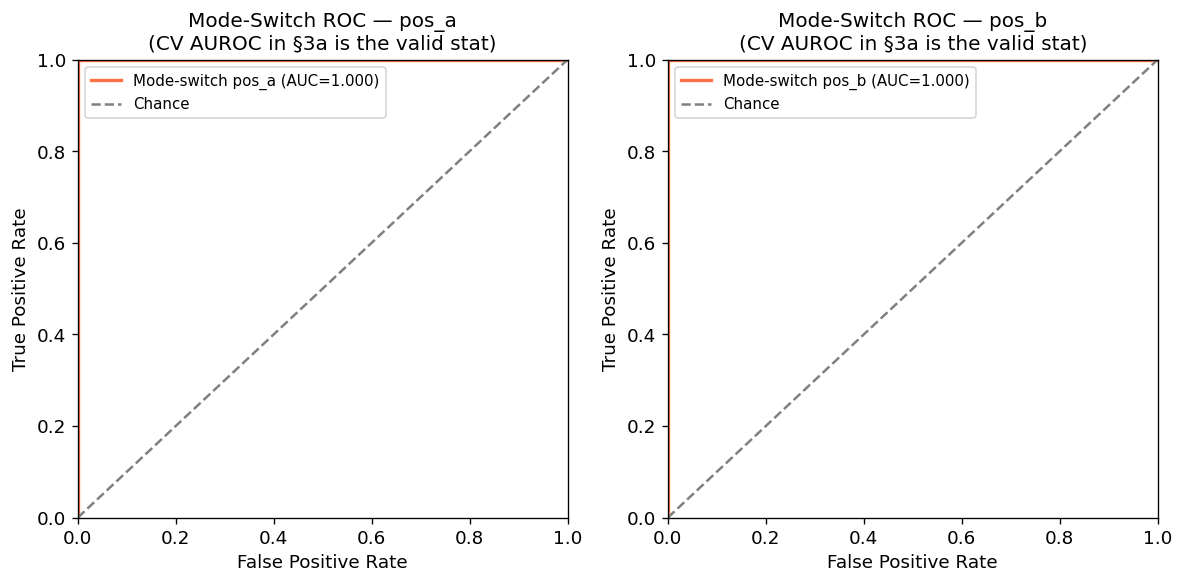

Saved → /content/drive/MyDrive/experiments/exp5_mode_switch_control/backup/figures/exp5_roc_curve.png


In [ ]:
# ── 3b: ROC curves (full-data fits) — saved to FIGURES_DIR ───────────────────
n_pos = len(lr_results)
fig, axes = plt.subplots(1, n_pos, figsize=(5 * n_pos, 5))
if n_pos == 1:
    axes = [axes]

for ax, (pos, r) in zip(axes, lr_results.items()):
    X_mode, y_mode, _, _ = mode_data[pos]
    y_score = r['clf'].predict_proba(r['X_mode_sc'])[:, 1]
    fpr, tpr, _ = roc_curve(y_mode, y_score)
    train_auc   = roc_auc_score(y_mode, y_score)
    ax.plot(fpr, tpr, lw=2, color='#FF7043',
            label=f'Mode-switch {pos} (AUC={train_auc:.3f})')
    ax.plot([0, 1], [0, 1], '--', color='gray', lw=1.5, label='Chance')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Mode-Switch ROC — {pos}\n(CV AUROC in §3a is the valid stat)')
    ax.legend(fontsize=9); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'exp5_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR / "exp5_roc_curve.png"}')

In [ ]:
# ── 3c: Top residual-stream dimensions in the mode-switch classifier ──────────
TOP_K = 20
for pos, r in lr_results.items():
    w    = r['clf'].coef_[0]
    top  = np.argsort(np.abs(w))[::-1][:TOP_K]
    print(f'\n{pos} — top {TOP_K} |coef| dimensions:')
    for rank, dim in enumerate(top):
        print(f'  {rank+1:2d}. dim {dim:4d}   w = {w[dim]:+.4f}')

    _coef_path = CACHE_DIR / f'exp5_mode_switch_coefs_{pos}.csv'
    pd.DataFrame({'dim': np.arange(D_MODEL), 'coef': w}).to_csv(_coef_path, index=False)
    print(f'  Saved → {_coef_path.name}')


pos_a — top 20 |coef| dimensions:
   1. dim  309   w = +0.0175
   2. dim 2087   w = -0.0174
   3. dim   95   w = +0.0167
   4. dim 1356   w = +0.0164
   5. dim 1553   w = -0.0156
   6. dim   40   w = -0.0154
   7. dim 1079   w = +0.0153
   8. dim 1231   w = +0.0152
   9. dim   25   w = -0.0149
  10. dim  747   w = +0.0149
  11. dim  432   w = +0.0149
  12. dim 1722   w = +0.0148
  13. dim 1198   w = +0.0146
  14. dim  722   w = +0.0146
  15. dim 1963   w = +0.0145
  16. dim    3   w = +0.0144
  17. dim  268   w = -0.0143
  18. dim 1422   w = +0.0141
  19. dim  883   w = +0.0138
  20. dim 1297   w = +0.0138
  Saved → exp5_mode_switch_coefs_pos_a.csv

pos_b — top 20 |coef| dimensions:
   1. dim   38   w = +0.0049
   2. dim  565   w = +0.0048
   3. dim  986   w = +0.0048
   4. dim 1021   w = -0.0048
   5. dim  231   w = -0.0048
   6. dim  419   w = +0.0048
   7. dim  189   w = +0.0048
   8. dim 1219   w = -0.0048
   9. dim   85   w = -0.0048
  10. dim 2087   w = -0.0048
  11. dim 1406   

## 4 — Comparison & Visualisation

| Mode-switch signal as % of exp1 CoT above chance | Verdict |
|---|---|
| **< 30 %** | ✓ Clean — exp1 encodes correctness, not format |
| **30 – 70 %** | Partial confound — report Exp 1 and Exp 5 side by side |
| **> 70 %** | ✗ Confound — reinterpret Exp 1 accordingly |

In [ ]:
# ── 4a: Comparison table — mode-switch vs. exp1 AUROCs ──────────────────────
rows = []
for pos, r in lr_results.items():
    m, s   = r['cv_auroc'].mean(), r['cv_auroc'].std()
    ref    = EXP1_AUROC.get(('cot', pos), np.nan)
    pct    = (m - 0.5) / max(ref - 0.5, 1e-6) * 100 if not np.isnan(ref) else np.nan

    if pct < 30:
        verdict = f'CLEAN ({pct:.0f}%)'
    elif pct < 70:
        verdict = f'PARTIAL CONFOUND ({pct:.0f}%)'
    else:
        verdict = f'CONFOUND ({pct:.0f}%)'

    rows.append({
        'Position': pos,
        'Exp1 CoT AUROC (real)':    round(ref, 4),
        'Mode-switch AUROC (mean)': round(m,   4),
        'Mode-switch Std':          round(s,   4),
        '% of exp1 signal':         round(pct, 1),
        'Verdict': verdict,
    })

df_compare = pd.DataFrame(rows)
print(df_compare.to_string(index=False))

_table_path = CACHE_DIR / 'exp5_comparison_table.csv'
df_compare.to_csv(_table_path, index=False)
print(f'\nSaved → {_table_path}')

Position  Exp1 CoT AUROC (real)  Mode-switch AUROC (mean)  Mode-switch Std  % of exp1 signal         Verdict
   pos_a                 0.7695                       1.0              0.0             185.5 CONFOUND (186%)
   pos_b                 0.6660                       1.0              0.0             301.3 CONFOUND (301%)

Saved → /content/drive/MyDrive/experiments/exp5_mode_switch_control/backup/cache/exp5_comparison_table.csv


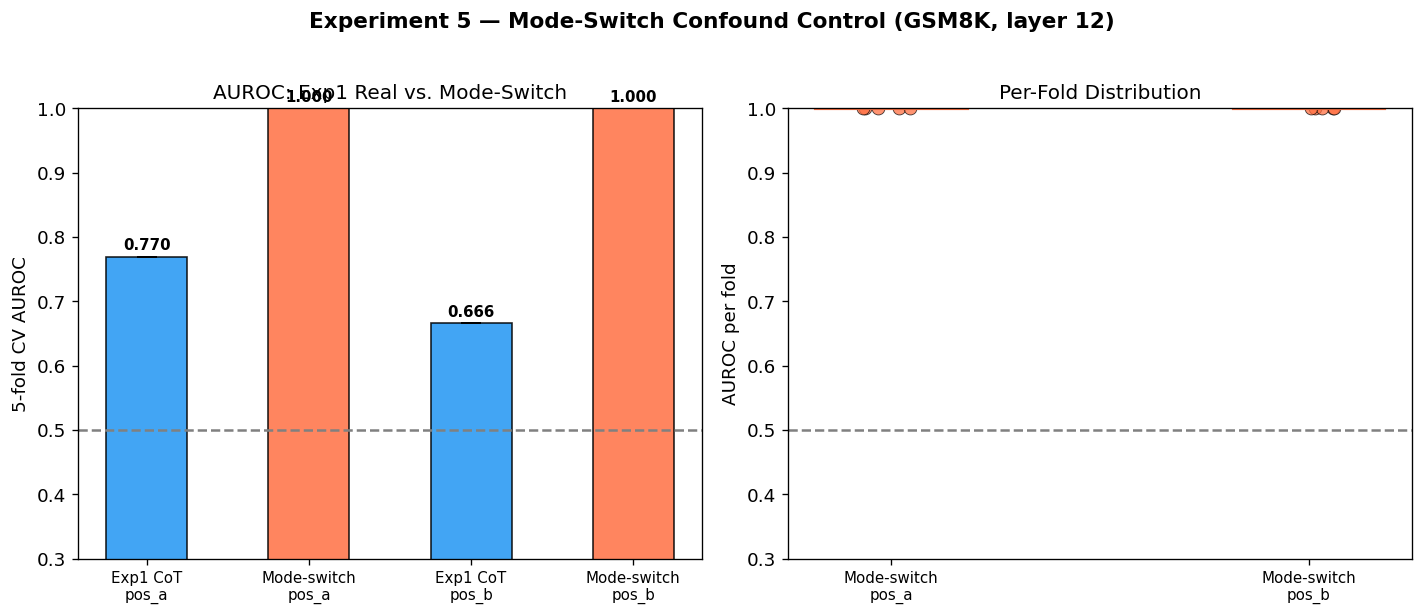

Saved → /content/drive/MyDrive/experiments/exp5_mode_switch_control/backup/figures/exp5_auroc_comparison.png


In [ ]:
# ── 4b: AUROC bar chart + per-fold strip ─────────────────────────────────────
n_pos  = len(lr_results)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

_labels_bar, _means_bar, _stds_bar, _colors_bar = [], [], [], []
_EXP1_COLOR, _MODE_COLOR = '#2196F3', '#FF7043'

for pos in lr_results:
    ref = EXP1_AUROC.get(('cot', pos), np.nan)
    m   = lr_results[pos]['cv_auroc'].mean()
    s   = lr_results[pos]['cv_auroc'].std()
    if not np.isnan(ref):
        _labels_bar.append(f'Exp1 CoT\n{pos}')
        _means_bar.append(ref)
        _stds_bar.append(0)
        _colors_bar.append(_EXP1_COLOR)
    _labels_bar.append(f'Mode-switch\n{pos}')
    _means_bar.append(m)
    _stds_bar.append(s)
    _colors_bar.append(_MODE_COLOR)

x = np.arange(len(_labels_bar))
bars = axes[0].bar(x, _means_bar, yerr=_stds_bar, capsize=6,
                   color=_colors_bar, alpha=0.85, edgecolor='black', width=0.5)
axes[0].axhline(0.5, ls='--', color='gray', lw=1.5, label='Chance')
axes[0].set_ylim(0.3, 1.0)
axes[0].set_xticks(x); axes[0].set_xticklabels(_labels_bar, fontsize=9)
axes[0].set_ylabel('5-fold CV AUROC')
axes[0].set_title('AUROC: Exp1 Real vs. Mode-Switch')
for bar, m in zip(bars, _means_bar):
    axes[0].text(bar.get_x() + bar.get_width()/2, m + 0.01,
                 f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')

rng = np.random.default_rng(0)
for j, (pos, r) in enumerate(lr_results.items()):
    folds = r['cv_auroc']
    jit   = rng.uniform(-0.07, 0.07, len(folds))
    axes[1].scatter(np.full(len(folds), j) + jit, folds, s=60,
                    color=_MODE_COLOR, alpha=0.75,
                    edgecolors='black', linewidths=0.5)
    axes[1].plot([j - 0.18, j + 0.18], [folds.mean()]*2, color=_MODE_COLOR, lw=2.5)
axes[1].axhline(0.5, ls='--', color='gray', lw=1.5)
axes[1].set_xticks(range(len(lr_results)))
axes[1].set_xticklabels([f'Mode-switch\n{p}' for p in lr_results], fontsize=9)
axes[1].set_ylim(0.3, 1.0)
axes[1].set_ylabel('AUROC per fold')
axes[1].set_title('Per-Fold Distribution')

plt.suptitle('Experiment 5 — Mode-Switch Confound Control (GSM8K, layer 12)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'exp5_auroc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR / "exp5_auroc_comparison.png"}')

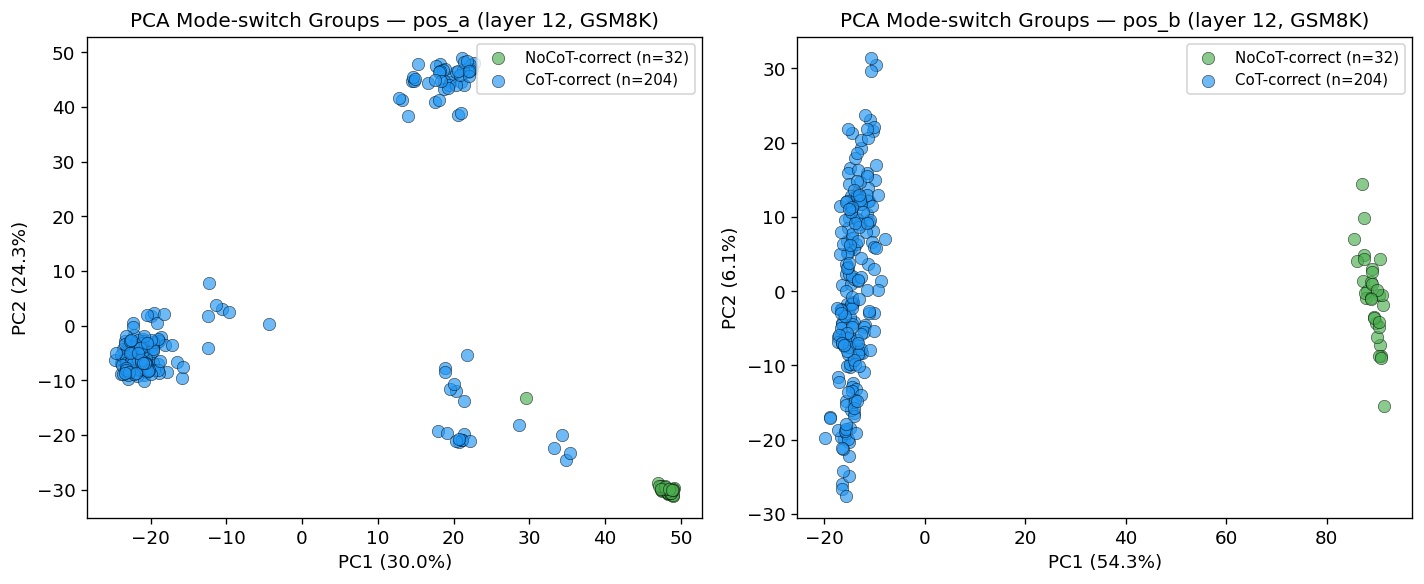

Saved → /content/drive/MyDrive/experiments/exp5_mode_switch_control/backup/figures/exp5_pca_projection.png


In [ ]:
# ── 4c: PCA projection of mode-switch groups ─────────────────────────────────
n_pos   = len(mode_data)
fig, axes = plt.subplots(1, n_pos, figsize=(6 * n_pos, 5))
if n_pos == 1:
    axes = [axes]

for ax, (pos, (X_mode, y_mode, n_cot_c, n_nocot_c)) in zip(axes, mode_data.items()):
    _pca  = PCA(n_components=2, random_state=SEED)
    X_pca = _pca.fit_transform(StandardScaler().fit_transform(X_mode))
    for cls, label, color in [(0, 'NoCoT-correct', '#4CAF50'), (1, 'CoT-correct', '#2196F3')]:
        mask = y_mode == cls
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=f'{label} (n={mask.sum()})',
                   alpha=0.65, s=55, edgecolors='black', linewidths=0.4, color=color)
    var = _pca.explained_variance_ratio_
    ax.set_xlabel(f'PC1 ({var[0]:.1%})'); ax.set_ylabel(f'PC2 ({var[1]:.1%})')
    ax.set_title(f'PCA Mode-switch Groups — {pos} (layer {LAYER}, GSM8K)')
    ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'exp5_pca_projection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR / "exp5_pca_projection.png"}')

## 5 — Final Results Snapshot

In [ ]:
# ── 5a: Verify all expected files exist on Drive ─────────────────────────────
_ts = datetime.now().strftime('%Y%m%d_%H%M%S')

_summary = {
    'timestamp':   _ts,
    'dataset':     'GSM8K, n=400, seed=42',
    'model':       MODEL_NAME,
    'layer':       LAYER,
    'positions':   list(lr_results.keys()),
    'results':     {
        pos: {
            'mode_switch_auroc_mean': float(r['cv_auroc'].mean()),
            'mode_switch_auroc_std':  float(r['cv_auroc'].std()),
            'exp1_cot_auroc':         EXP1_AUROC.get(('cot', pos)),
            'pct_of_exp1_signal':     float(
                (r['cv_auroc'].mean() - 0.5) /
                max(EXP1_AUROC.get(('cot', pos), 0.5) - 0.5, 1e-6) * 100
            ),
        }
        for pos, r in lr_results.items()
    },
    'lr_hyperparams': {'C': LR_C, 'cv_folds': CV_FOLDS, 'solver': 'lbfgs'},
    'cache_dir':   str(CACHE_DIR),
    'figures_dir': str(FIGURES_DIR),
}

_summary_path = CACHE_DIR / f'exp5_summary_{_ts}.json'
with open(_summary_path, 'w') as fh:
    json.dump(_summary, fh, indent=2)

print('── Exp 5 File Verification ──────────────────────────────────────────────')
_expected = [
    CACHE_DIR   / 'exp5_comparison_table.csv',
    FIGURES_DIR / 'exp5_auroc_comparison.png',
    FIGURES_DIR / 'exp5_roc_curve.png',
    FIGURES_DIR / 'exp5_pca_projection.png',
    _summary_path,
]
_expected += [CACHE_DIR / f'X_mode_{p}.npy'              for p in lr_results]
_expected += [CACHE_DIR / f'y_mode_{p}.npy'              for p in lr_results]
_expected += [CACHE_DIR / f'mode_switch_lr_{p}.pkl'      for p in lr_results]
_expected += [CACHE_DIR / f'exp5_mode_switch_coefs_{p}.csv' for p in lr_results]

all_ok = True
for p in _expected:
    exists = p.exists()
    size   = f'({p.stat().st_size/1024:.1f} KB)' if exists else ''
    print(f'  [{"OK" if exists else "MISSING"}]  {p.name:<50s}  {size}')
    all_ok = all_ok and exists

print()
for pos, r in lr_results.items():
    ref = EXP1_AUROC.get(('cot', pos), np.nan)
    pct = (r['cv_auroc'].mean() - 0.5) / max(ref - 0.5, 1e-6) * 100
    print(f'  {pos}: mode-switch={r["cv_auroc"].mean():.3f} ± {r["cv_auroc"].std():.3f}  '
          f'exp1_ref={ref:.3f}  %={pct:.0f}%')
print()
print('All files on Drive: OK' if all_ok else 'WARNING: some files missing')

── Exp 5 File Verification ──────────────────────────────────────────────
  [OK]  exp5_comparison_table.csv                           (0.2 KB)
  [OK]  exp5_auroc_comparison.png                           (65.8 KB)
  [OK]  exp5_roc_curve.png                                  (74.6 KB)
  [OK]  exp5_pca_projection.png                             (166.0 KB)
  [OK]  exp5_summary_20260620_134314.json                   (0.8 KB)
  [OK]  X_mode_pos_a.npy                                    (2124.1 KB)
  [OK]  X_mode_pos_b.npy                                    (2124.1 KB)
  [OK]  y_mode_pos_a.npy                                    (2.0 KB)
  [OK]  y_mode_pos_b.npy                                    (2.0 KB)
  [OK]  mode_switch_lr_pos_a.pkl                            (2197.3 KB)
  [OK]  mode_switch_lr_pos_b.pkl                            (2197.3 KB)
  [OK]  exp5_mode_switch_coefs_pos_a.csv                    (59.2 KB)
  [OK]  exp5_mode_switch_coefs_pos_b.csv                    (59.4 KB)

  pos_a: m

## 6 — Results & Interpretation

> **Scope note:** The experiment plan specifies Layer 12, Position A only. We additionally tested Position B at zero extra compute, providing a stronger mechanistic anchor (see below).

---

### Numeric Results

| Position | Exp 1 CoT AUROC | Exp 1 NoCoT AUROC | Mode-Switch AUROC (5-fold CV) | Verdict |
|---|---|---|---|---|
| pos_a | 0.770 | 0.730 | **1.000 ± 0.000** | Conditions geometrically non-overlapping |
| pos_b | 0.666 | 0.736 | **1.000 ± 0.000** | Conditions geometrically non-overlapping |

**Geometric statistics — correctly-answered problems only (n = 204 CoT-correct + 32 NoCoT-correct):**

| Position | Cosine sim (condition means) | ‖CoT‖ mean ± std | ‖NoCoT‖ mean ± std | MW p-value |
|---|---|---|---|---|
| pos_a | 0.682 | 145.1 ± 8.9 | 158.7 ± 3.9 | p ≈ 0 |
| pos_b | 0.776 | 185.7 ± 3.0 | 158.9 ± 3.1 | p ≈ 0 |

---

### What the Result Means

An L2-regularised logistic regression with only 236 examples achieves **AUROC = 1.000, zero variance across all 5 CV folds** when distinguishing CoT-correct from NoCoT-correct activations. The notebook's pre-specified rule labels this a "CONFOUND (>70%)" — but the correct interpretation requires separating two questions.

#### Question 1 — Does this confound Experiment 1's correctness classifiers?

**No.** Experiment 1 trains two fully independent classifiers, each within one condition:

- **Classifier A (CoT):** CoT-correct vs. CoT-incorrect → AUROC = 0.770
- **Classifier B (NoCoT):** NoCoT-correct vs. NoCoT-incorrect → AUROC = 0.730

Within each training set, prompt format is a constant — every sample shares the same format, so a format detector has zero discriminative power. The mode-switch signal (AUROC = 1.000) cannot explain AUROC > 0.5 on Exp 1's within-condition task. **Experiment 1's results are not confounded.**

#### Question 2 — What does Experiment 5 actually reveal?

It reveals that **CoT and NoCoT activations occupy geometrically distinct manifolds** at layer 12. Four signals converge on this:

1. **Perfect separability at pos_a (AUROC = 1.000):** Zero overlap between the two conditions across all CV folds — they are not just different on average, there is no mixing at the boundary.

2. **Perfect separability at pos_b (AUROC = 1.000):** pos_b is the *last token of the prompt*, captured before the model writes a single generation token. The two conditions are fully separable at this pre-generation snapshot. This is the key mechanistic datum: **the manifold shift is caused by the prompt suffix itself** ("Let's think step by step." vs. "Answer:"), not by anything computed during the chain of thought.

3. **Norm reversal between positions:** At pos_b (before generation), CoT norms are *larger* (185.7 vs. 158.9). By pos_a (after reasoning), CoT norms are *smaller* (145.1 vs. 158.7) and their variance has more than doubled (±8.9 vs. ±3.9). The chain-of-thought reasoning pushes the residual stream through a more diverse trajectory, landing in a lower-norm, higher-variance region — a geometric signature of richer, problem-specific computation.

4. **Low cosine similarity between condition means:** 0.68 at pos_a, 0.78 at pos_b. The mean activation vectors point in genuinely different directions in 2304-dimensional space; this is a deep geometric shift, not a scalar magnitude change.

#### Caveat — who are the 32 NoCoT-correct problems?

Only 32 of 400 GSM8K problems are solved correctly without chain-of-thought (8% accuracy). These are almost certainly the easiest problems in the sample. Their residual-stream activations may differ from CoT-correct activations partly due to prompt format, and partly because *easy problems produce intrinsically different activations regardless of format*. The perfect AUROC cannot be attributed to format alone. **Experiment 4 (flipped-problems classifier)** addresses this directly by comparing CoT vs. NoCoT activations on the *same set of problems*, controlling for problem difficulty entirely.

---

### Connection to the Central Research Question

The thesis asks: *does CoT add discriminative correctness information to the residual stream (genuine computation), or was the answer already encoded before writing begins (rationalization)?*

Experiment 5 contributes at two levels:

**Re: the Δ comparison in Experiment 1**

Δ = AUROC_CoT − AUROC_NoCoT is computed between classifiers trained on different geometric manifolds (cosine similarity of condition means: 0.68–0.78). A positive Δ at pos_a (0.770 − 0.730 = +0.040) means CoT produces *more linearly separable* correctness signal within its own activation space. This is real, but should be read as: "CoT creates a computational regime in which correct and incorrect answers are more geometrically distinct," not "the same representation, amplified."

**Re: rationalization vs. genuine computation**

The pos_b finding shows that the model enters "CoT mode" *before writing any reasoning steps* — the computation regime is set by the prompt structure. This is not evidence of rationalization (the specific answer is not yet encoded at pos_b). It is evidence that CoT triggers a qualitatively different processing mode from the first generated token onward. Combined with Exp 1's correctness signal at pos_a (AUROC = 0.770 vs. 0.5 chance), the data supports **genuine computation**: CoT activates a distinct regime that is more predictive of answer correctness — not merely a post-hoc justification of an already-decided answer.

---

### Implications for the Thesis

**Thesis Table 1 — control row:**

| Experiment | Representation | Layer | Position | AUROC | Note |
|---|---|---|---|---|---|
| Exp 5 — Mode-switch | Raw residual | 12 | pos_a | 1.000 | Both conditions correct; format perfectly detectable — Exp 1 classifiers are within-condition and unaffected |

Footnote: *The AUROC = 1.000 indicates geometric non-overlap between conditions, not a confound in Exp 1's within-condition correctness classifiers. See §Exp 5 for full discussion.*

**Implication for Exp 2 (SAE decomposition):** Within-condition SAE correctness classifiers remain valid. The between-condition feature gap reflects both format-encoding and reasoning quality; Experiment 4 (flipped problems) is required to disentangle the two.

**Broader mechanistic finding:** The AUROC = 1.000 result is itself a contribution to the thesis. CoT does not merely change what the model outputs — it fundamentally restructures the residual-stream geometry from the moment the prompt suffix is processed. The layer-12 residual stream encodes the *computation regime* as a first-class geometric property, before any reasoning tokens are written. This is direct geometric evidence that CoT engages a qualitatively different computational mode, contextualising and grounding all correctness-signal results in Experiments 1–4.
